In [1]:
# Problema: Decidir cuánto alimento comprar a cada proveedor y hacia qué destinos enviarlo, con oferta limitada y costos de transporte distintos, para atender la demanda al menor costo total.
# El aprovisionamiento y la distribucion se deciden juntos: no se resuelven por separado.

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.figure import Figure
from IPython.display import display
from IPython import get_ipython
import pulp

data_dir = Path("../data")
submission_dir = Path("../submission")
get_ipython().run_line_magic("matplotlib", "inline")
plt.rcParams.update({"figure.dpi": 110, "font.size": 10})
display(["suppliers.csv", "destinations.csv", "transport.csv"])

['suppliers.csv', 'destinations.csv', 'transport.csv']

In [2]:
# Respuesta humanitaria sintetica: proveedores, destinos y costos de transporte por ruta.

suppliers = (
    pd.read_csv(data_dir / "suppliers.csv")
    .sort_values("supplier_id")
    .reset_index(drop=True)
)
destinations = (
    pd.read_csv(data_dir / "destinations.csv")
    .sort_values("destination_id")
    .reset_index(drop=True)
)
transport = pd.read_csv(data_dir / "transport.csv")
display(suppliers, destinations, transport)

,supplier_id,available_tonnes,procurement_cost_per_tonne
0,S1,120,250
1,S2,300,280
2,S3,250,268


,destination_id,required_tonnes
0,D1,150
1,D2,150
2,D3,120
3,D4,130


,supplier_id,destination_id,transport_cost_per_tonne
0,S1,D1,20
1,S1,D2,25
2,S1,D3,60
3,S1,D4,70
4,S2,D1,35
5,S2,D2,30
6,S2,D3,20
7,S2,D4,25
8,S3,D1,50
9,S3,D2,45


In [3]:
# La oferta total debe alcanzar para cubrir la demanda humanitaria total antes de decidir nada.

assert len(suppliers) == 3 and suppliers.supplier_id.is_unique
assert len(destinations) == 4 and destinations.destination_id.is_unique
assert len(transport) == len(suppliers) * len(destinations)
assert (
    not suppliers.isna().any().any()
    and not destinations.isna().any().any()
    and not transport.isna().any().any()
)
assert (
    suppliers.available_tonnes.gt(0).all()
    and suppliers.procurement_cost_per_tonne.gt(0).all()
)
assert (
    destinations.required_tonnes.gt(0).all()
    and transport.transport_cost_per_tonne.gt(0).all()
)
total_supply = suppliers.available_tonnes.sum()
total_demand = destinations.required_tonnes.sum()
assert total_supply >= total_demand
print(
    f"{len(suppliers)} proveedores; {len(destinations)} destinos; oferta total {total_supply} t; demanda total {total_demand} t."
)

3 proveedores; 4 destinos; oferta total 670 t; demanda total 550 t.


In [4]:
# El costo de compra y el costo de transporte se observan por separado antes de combinarlos.

supplier_ids = suppliers.supplier_id.tolist()
destination_ids = destinations.destination_id.tolist()
procurement_cost = suppliers.set_index("supplier_id").procurement_cost_per_tonne
transport_matrix = transport.pivot(
    index="supplier_id", columns="destination_id", values="transport_cost_per_tonne"
).loc[supplier_ids, destination_ids]
display(procurement_cost.rename("procurement_cost_per_tonne"))
display(transport_matrix)

supplier_id
S1    250
S2    280
S3    268
Name: procurement_cost_per_tonne, dtype: int64

destination_id,D1,D2,D3,D4
supplier_id,,,,
S1,20,25,60,70
S2,35,30,20,25
S3,50,45,15,10


In [5]:
# El costo de compra mas bajo no siempre produce el costo entregado mas bajo en cada destino.

landed_cost = transport_matrix.add(procurement_cost, axis=0)
cheapest_per_destination = pd.DataFrame(
    {
        "cheapest_supplier": landed_cost.idxmin(axis=0),
        "cheapest_landed_cost": landed_cost.min(axis=0),
    }
)
display(landed_cost)
display(cheapest_per_destination)

destination_id,D1,D2,D3,D4
supplier_id,,,,
S1,270,275,310,320
S2,315,310,300,305
S3,318,313,283,278


,cheapest_supplier,cheapest_landed_cost
destination_id,,
D1,S1,270
D2,S1,275
D3,S3,283
D4,S3,278


In [6]:
# El mismo calculo de costo evaluara heuristicas y optimizacion: costo entregado total.

supply = suppliers.set_index("supplier_id").available_tonnes.to_dict()
demand = destinations.set_index("destination_id").required_tonnes.to_dict()


def total_delivered_cost(flows):
    return float(
        sum(tonnes * landed_cost.loc[s, d] for (s, d), tonnes in flows.items())
    )


print(
    "Funcion de costo definida: costo entregado total = suma de toneladas por costo puesto en destino."
)

Funcion de costo definida: costo entregado total = suma de toneladas por costo puesto en destino.


In [7]:
# Heuristica 1: comprar primero donde el precio de compra es mas bajo, sin mirar el transporte.


def procurement_first_plan():
    supplier_priority = suppliers.sort_values(
        "procurement_cost_per_tonne"
    ).supplier_id.tolist()
    remaining_supply = dict(supply)
    remaining_demand = dict(demand)
    flows = {}
    for s in supplier_priority:
        for d in destination_ids:
            if remaining_supply[s] <= 0:
                break
            take = min(remaining_supply[s], remaining_demand[d])
            if take > 0:
                flows[(s, d)] = flows.get((s, d), 0.0) + take
                remaining_supply[s] -= take
                remaining_demand[d] -= take
    return flows


procurement_first_flows = procurement_first_plan()
procurement_first_cost = total_delivered_cost(procurement_first_flows)
print(f"Costo entregado, compra primero: {procurement_first_cost:,.0f}")

Costo entregado, compra primero: 163,350


In [8]:
# Heuristica 2: en cada destino, usar la fuente de menor costo puesto en destino disponible.


def landed_cost_greedy_plan(destination_order):
    remaining_supply = dict(supply)
    flows = {}
    for d in destination_order:
        need = demand[d]
        ranked_suppliers = landed_cost[d].sort_values().index.tolist()
        for s in ranked_suppliers:
            if need <= 0:
                break
            take = min(remaining_supply[s], need)
            if take > 0:
                flows[(s, d)] = flows.get((s, d), 0.0) + take
                remaining_supply[s] -= take
                need -= take
    return flows


print(
    "Funcion de asignacion greedy definida: el resultado depende del orden en que se procesan los destinos."
)

Funcion de asignacion greedy definida: el resultado depende del orden en que se procesan los destinos.


In [9]:
# Orden A: procesamos los destinos en su orden natural D1, D2, D3, D4.

greedy_a_flows = landed_cost_greedy_plan(["D1", "D2", "D3", "D4"])
greedy_a_cost = total_delivered_cost(greedy_a_flows)
print(f"Costo entregado, greedy orden D1-D2-D3-D4: {greedy_a_cost:,.0f}")

Costo entregado, greedy orden D1-D2-D3-D4: 158,450


In [10]:
# Orden B: el mismo algoritmo; solo cambia el orden en que se atienden los destinos.

greedy_b_flows = landed_cost_greedy_plan(["D2", "D1", "D3", "D4"])
greedy_b_cost = total_delivered_cost(greedy_b_flows)
print(f"Costo entregado, greedy orden D2-D1-D3-D4: {greedy_b_cost:,.0f}")

Costo entregado, greedy orden D2-D1-D3-D4: 159,650


In [11]:
# El orden A alcanza el optimo por coincidencia; no es evidencia de que la heuristica sea optima en general.

order_comparison = pd.DataFrame(
    [
        ["orden D1-D2-D3-D4", greedy_a_cost],
        ["orden D2-D1-D3-D4", greedy_b_cost],
    ],
    columns=["procesamiento", "costo_entregado"],
)
display(order_comparison)
print(
    f"Diferencia atribuible unicamente al orden de procesamiento: {greedy_b_cost - greedy_a_cost:,.0f}"
)

,procesamiento,costo_entregado
0,orden D1-D2-D3-D4,158450.0
1,orden D2-D1-D3-D4,159650.0


Diferencia atribuible unicamente al orden de procesamiento: 1,200


In [12]:
# Ninguna heuristica considera el costo de oportunidad de la capacidad escasa de S1.

heuristics_preview = pd.DataFrame(
    [
        ["compra primero", procurement_first_cost],
        ["greedy (D1 primero)", greedy_a_cost],
        ["greedy (D2 primero)", greedy_b_cost],
    ],
    columns=["estrategia", "costo_entregado"],
)
display(heuristics_preview)

,estrategia,costo_entregado
0,compra primero,163350.0
1,greedy (D1 primero),158450.0
2,greedy (D2 primero),159650.0


In [13]:
# S1 es la fuente mas barata para D1 y D2, pero sus 120 toneladas no alcanzan para ninguno de los dos por si solo.

opportunity_cost_rows = []
for d in ["D1", "D2"]:
    ranked = landed_cost[d].sort_values()
    cheapest_supplier, cheapest_cost = ranked.index[0], ranked.iloc[0]
    next_supplier, next_cost = ranked.index[1], ranked.iloc[1]
    opportunity_cost_rows.append(
        [
            d,
            cheapest_supplier,
            cheapest_cost,
            next_supplier,
            next_cost,
            next_cost - cheapest_cost,
        ]
    )
opportunity_cost = pd.DataFrame(
    opportunity_cost_rows,
    columns=[
        "destination_id",
        "cheapest_supplier",
        "cheapest_landed_cost",
        "next_supplier",
        "next_landed_cost",
        "penalty_per_tonne",
    ],
)
display(opportunity_cost)
print(
    "La capacidad escasa de S1 vale mas en el destino con mayor penalizacion por reemplazo."
)

,destination_id,cheapest_supplier,cheapest_landed_cost,next_supplier,next_landed_cost,penalty_per_tonne
0,D1,S1,270,S2,315,45
1,D2,S1,275,S2,310,35


La capacidad escasa de S1 vale mas en el destino con mayor penalizacion por reemplazo.


In [14]:
# W04-W06 enumeraron alternativas discretas; aqui x[s,d] es continuo y no hay un conjunto finito que enumerar.

print(
    "W04-W06: alternativas discretas finitas -> la enumeracion exhaustiva expone el espacio de busqueda."
)
print(
    "W07: x[s,d] >= 0 es continuo -> existen infinitas asignaciones factibles entre proveedores y destinos."
)
print(
    "No existe una enumeracion exhaustiva finita; la programacion matematica es la herramienta natural."
)

W04-W06: alternativas discretas finitas -> la enumeracion exhaustiva expone el espacio de busqueda.
W07: x[s,d] >= 0 es continuo -> existen infinitas asignaciones factibles entre proveedores y destinos.
No existe una enumeracion exhaustiva finita; la programacion matematica es la herramienta natural.


In [15]:
# MODEL
# ---------------------------------------------------------------------
# Sets:
#   s in SUPPLIERS
#   d in DESTINATIONS
#
# Parameters:
#   supply[s]       available tonnes at supplier s
#   demand[d]       required tonnes at destination d
#   purchase[s]     procurement cost per tonne
#   transport[s,d]  transport cost per tonne
#
# Derived:
#   landed[s,d] = purchase[s] + transport[s,d]
#
# Decision variable:
#   x[s,d] >= 0
#       tonnes shipped from supplier s to destination d
#
# Objective:
#   minimize total_delivered_cost:
#       sum{s in SUPPLIERS, d in DESTINATIONS}
#           landed[s,d] * x[s,d]
#
# Constraints:
#   subject to supplier_capacity{s in SUPPLIERS}:
#       sum{d in DESTINATIONS} x[s,d] <= supply[s]
#
#   subject to destination_requirement{d in DESTINATIONS}:
#       sum{s in SUPPLIERS} x[s,d] = demand[d]

display(
    pd.Series({"suppliers": len(supplier_ids), "destinations": len(destination_ids)})
)

suppliers       3
destinations    4
dtype: int64

In [16]:
# Construimos el mismo modelo con PuLP; HiGHS lo resolvera a continuacion.

model = pulp.LpProblem("humanitarian_food_aid", pulp.LpMinimize)
x = {
    (s, d): pulp.LpVariable(f"x_{s}_{d}", lowBound=0, cat="Continuous")
    for s in supplier_ids
    for d in destination_ids
}
model += pulp.lpSum(
    landed_cost.loc[s, d] * x[s, d] for s in supplier_ids for d in destination_ids
)
for s in supplier_ids:
    model += pulp.lpSum(x[s, d] for d in destination_ids) <= supply[s]
for d in destination_ids:
    model += pulp.lpSum(x[s, d] for s in supplier_ids) == demand[d]
display(
    pd.Series(
        {
            "x_variables": len(x),
            "supplier_capacity_constraints": len(supplier_ids),
            "destination_requirement_constraints": len(destination_ids),
        }
    )
)

x_variables                            12
supplier_capacity_constraints           3
destination_requirement_constraints     4
dtype: int64

In [17]:
# Resolvemos el modelo continuo con un solver profesional: no hay alternativa de enumeracion.

solver = pulp.HiGHS(msg=False)
status = model.solve(solver)
assert pulp.LpStatus[status] == "Optimal"
solver_objective = pulp.value(model.objective)
solver_flows = {
    (s, d): x[s, d].value()
    for s in supplier_ids
    for d in destination_ids
    if x[s, d].value() > 1e-6
}
display(
    pd.DataFrame(
        [(s, d, round(t, 3)) for (s, d), t in solver_flows.items()],
        columns=["supplier_id", "destination_id", "tonnes"],
    )
)
print(
    f"Estado: {pulp.LpStatus[status]}; costo total entregado: {solver_objective:,.2f}"
)

,supplier_id,destination_id,tonnes
0,S1,D1,120.0
1,S2,D1,30.0
2,S2,D2,150.0
3,S3,D3,120.0
4,S3,D4,130.0


Estado: Optimal; costo total entregado: 158,450.00


In [18]:
# El costo entregado se descompone en compra y transporte; ambos deben sumar el total.

procurement_cost_total = sum(
    t * procurement_cost[s] for (s, d), t in solver_flows.items()
)
transport_cost_total = sum(
    t * transport_matrix.loc[s, d] for (s, d), t in solver_flows.items()
)
delivered_cost_total = procurement_cost_total + transport_cost_total
assert np.isclose(delivered_cost_total, solver_objective)
display(
    pd.Series(
        {
            "procurement_cost": procurement_cost_total,
            "transport_cost": transport_cost_total,
            "delivered_cost": delivered_cost_total,
        }
    )
)

procurement_cost    147400.0
transport_cost       11050.0
delivered_cost      158450.0
dtype: float64

In [19]:
# La utilizacion de cada proveedor y el cumplimiento de cada destino verifican el plan optimizado.

tonnes_used = {
    s: sum(t for (sup, d), t in solver_flows.items() if sup == s) for s in supplier_ids
}
supplier_utilization = suppliers.copy()
supplier_utilization["tonnes_used"] = supplier_utilization.supplier_id.map(tonnes_used)
supplier_utilization["utilization_pct"] = (
    100 * supplier_utilization.tonnes_used / supplier_utilization.available_tonnes
)

tonnes_received = {
    d: sum(t for (s, dest), t in solver_flows.items() if dest == d)
    for d in destination_ids
}
destination_fulfillment = destinations.copy()
destination_fulfillment["tonnes_received"] = destination_fulfillment.destination_id.map(
    tonnes_received
)
destination_fulfillment["fulfillment_pct"] = (
    100
    * destination_fulfillment.tonnes_received
    / destination_fulfillment.required_tonnes
)
display(supplier_utilization, destination_fulfillment)

,supplier_id,available_tonnes,procurement_cost_per_tonne,tonnes_used,utilization_pct
0,S1,120,250,120.0,100.0
1,S2,300,280,180.0,60.0
2,S3,250,268,250.0,100.0


,destination_id,required_tonnes,tonnes_received,fulfillment_pct
0,D1,150,150.0,100.0
1,D2,150,150.0,100.0
2,D3,120,120.0,100.0
3,D4,130,130.0,100.0


In [20]:
# Validamos el plan optimizado de forma independiente: no existe una busqueda exhaustiva de referencia.

assert all(t >= -1e-6 for t in solver_flows.values())
assert all(tonnes_used[s] <= supply[s] + 1e-6 for s in supplier_ids)
assert all(np.isclose(tonnes_received[d], demand[d]) for d in destination_ids)
assert np.isclose(sum(solver_flows.values()), sum(demand.values()))
assert np.isclose(sum(demand.values()), 550)
recomputed_objective = total_delivered_cost(solver_flows)
assert np.isclose(recomputed_objective, solver_objective)
assert np.isclose(procurement_cost_total + transport_cost_total, solver_objective)
assert solver_objective <= procurement_first_cost + 1e-6
assert solver_objective <= greedy_a_cost + 1e-6
assert solver_objective <= greedy_b_cost + 1e-6
print(
    "Validado: flujos factibles, demanda exacta y costos consistentes con las heuristicas."
)

Validado: flujos factibles, demanda exacta y costos consistentes con las heuristicas.


In [21]:
# El plan optimizado iguala al mejor orden greedy y supera a las demas referencias.

plan_comparison = pd.DataFrame(
    [
        ["procurement_first", procurement_first_cost],
        ["landed_greedy_D1_first", greedy_a_cost],
        ["landed_greedy_D2_first", greedy_b_cost],
        ["optimized", solver_objective],
    ],
    columns=["strategy", "total_delivered_cost"],
)
plan_comparison["gap_vs_optimized"] = (
    plan_comparison.total_delivered_cost - solver_objective
)
display(plan_comparison)

,strategy,total_delivered_cost,gap_vs_optimized
0,procurement_first,163350.0,4900.0
1,landed_greedy_D1_first,158450.0,0.0
2,landed_greedy_D2_first,159650.0,1200.0
3,optimized,158450.0,0.0


In [22]:
# Resolvemos el mismo modelo para distintos niveles de capacidad en S1.


def solve_for_supply(supply_override):
    scenario_model = pulp.LpProblem("humanitarian_food_aid_scenario", pulp.LpMinimize)
    scenario_x = {
        (s, d): pulp.LpVariable(f"sx_{s}_{d}", lowBound=0, cat="Continuous")
        for s in supplier_ids
        for d in destination_ids
    }
    scenario_model += pulp.lpSum(
        landed_cost.loc[s, d] * scenario_x[s, d]
        for s in supplier_ids
        for d in destination_ids
    )
    for s in supplier_ids:
        scenario_model += (
            pulp.lpSum(scenario_x[s, d] for d in destination_ids) <= supply_override[s]
        )
    for d in destination_ids:
        scenario_model += (
            pulp.lpSum(scenario_x[s, d] for s in supplier_ids) == demand[d]
        )
    scenario_solver = pulp.HiGHS(msg=False)
    scenario_status = scenario_model.solve(scenario_solver)
    assert pulp.LpStatus[scenario_status] == "Optimal"
    scenario_objective = pulp.value(scenario_model.objective)
    scenario_flows = {
        (s, d): scenario_x[s, d].value()
        for s in supplier_ids
        for d in destination_ids
        if scenario_x[s, d].value() > 1e-6
    }
    return scenario_objective, scenario_flows


print(
    "Funcion de escenario definida: resuelve el mismo modelo con una oferta distinta en S1."
)

Funcion de escenario definida: resuelve el mismo modelo con una oferta distinta en S1.


In [23]:
# Evaluamos S1 en 120, 150 y 180 toneladas manteniendo todo lo demas igual.

sensitivity_rows = []
previous_cost = None
for s1_capacity in [120, 150, 180]:
    supply_scenario = dict(supply)
    supply_scenario["S1"] = s1_capacity
    scenario_objective, scenario_flows = solve_for_supply(supply_scenario)
    cost_reduction = (
        None if previous_cost is None else previous_cost - scenario_objective
    )
    sensitivity_rows.append(
        [
            s1_capacity,
            scenario_objective,
            scenario_flows.get(("S1", "D1"), 0.0),
            scenario_flows.get(("S1", "D2"), 0.0),
            cost_reduction,
        ]
    )
    previous_cost = scenario_objective
capacity_sensitivity = pd.DataFrame(
    sensitivity_rows,
    columns=[
        "s1_capacity_tonnes",
        "total_delivered_cost",
        "s1_to_d1_tonnes",
        "s1_to_d2_tonnes",
        "cost_reduction",
    ],
)
display(capacity_sensitivity)

,s1_capacity_tonnes,total_delivered_cost,s1_to_d1_tonnes,s1_to_d2_tonnes,cost_reduction
0,120,158450.0,120.0,0.0,NaN
1,150,157100.0,150.0,0.0,1350.0
2,180,156050.0,150.0,30.0,1050.0


In [24]:
# El ahorro por tonelada adicional de S1 coincide con la penalizacion de reemplazo calculada antes.

capacity_sensitivity["capacity_increase"] = (
    capacity_sensitivity.s1_capacity_tonnes.diff()
)
capacity_sensitivity["savings_per_tonne"] = (
    capacity_sensitivity.cost_reduction / capacity_sensitivity.capacity_increase
)
display(
    capacity_sensitivity[
        [
            "s1_capacity_tonnes",
            "total_delivered_cost",
            "cost_reduction",
            "capacity_increase",
            "savings_per_tonne",
        ]
    ]
)
print(
    f"120 -> 150 t: {capacity_sensitivity.savings_per_tonne.iloc[1]:.0f} ahorrados por tonelada (penalizacion D1)."
)
print(
    f"150 -> 180 t: {capacity_sensitivity.savings_per_tonne.iloc[2]:.0f} ahorrados por tonelada (penalizacion D2)."
)

,s1_capacity_tonnes,total_delivered_cost,cost_reduction,capacity_increase,savings_per_tonne
0,120,158450.0,NaN,NaN,NaN
1,150,157100.0,1350.0,30.0,45.0
2,180,156050.0,1050.0,30.0,35.0


120 -> 150 t: 45 ahorrados por tonelada (penalizacion D1).
150 -> 180 t: 35 ahorrados por tonelada (penalizacion D2).


In [25]:
# Registramos el plan de embarques optimizado con su costo puesto en destino.

shipment_plan = pd.DataFrame(
    [
        [
            s,
            d,
            t,
            procurement_cost[s],
            transport_matrix.loc[s, d],
            landed_cost.loc[s, d],
            t * landed_cost.loc[s, d],
        ]
        for (s, d), t in sorted(solver_flows.items())
    ],
    columns=[
        "supplier_id",
        "destination_id",
        "tonnes",
        "procurement_cost_per_tonne",
        "transport_cost_per_tonne",
        "landed_cost_per_tonne",
        "delivered_cost",
    ],
)
display(shipment_plan)

,supplier_id,destination_id,tonnes,procurement_cost_per_tonne,transport_cost_per_tonne,landed_cost_per_tonne,delivered_cost
0,S1,D1,120.0,250,20,270,32400.0
1,S2,D1,30.0,280,35,315,9450.0
2,S2,D2,150.0,280,30,310,46500.0
3,S3,D3,120.0,268,15,283,33960.0
4,S3,D4,130.0,268,10,278,36140.0


In [26]:
# Construimos el planeador sin mostrarlo hasta completar todas sus capas.

supplier_colors = dict(zip(supplier_ids, plt.get_cmap("tab10").colors))
supplier_y = dict(zip(supplier_ids, np.linspace(0.8, 0.2, len(supplier_ids))))
destination_y = dict(zip(destination_ids, np.linspace(0.9, 0.1, len(destination_ids))))

planner = Figure(figsize=(11, 8), layout="constrained")
planner_ax = planner.add_subplot(111)
planner_ax.axis("off")

for s in supplier_ids:
    planner_ax.scatter(
        0,
        supplier_y[s],
        s=1400,
        marker="s",
        color=supplier_colors[s],
        edgecolor="black",
        zorder=3,
    )
    label = (
        f"{s}\ndisponible {supply[s]:.0f} t\nusado {tonnes_used[s]:.0f} t "
        f"({100 * tonnes_used[s] / supply[s]:.0f}%)"
    )
    planner_ax.annotate(
        label,
        (0, supplier_y[s]),
        xytext=(-24, 0),
        textcoords="offset points",
        ha="right",
        va="center",
        fontsize=8,
    )

for d in destination_ids:
    planner_ax.scatter(
        1,
        destination_y[d],
        s=1400,
        marker="o",
        color="#8299ad",
        edgecolor="black",
        zorder=3,
    )
    label = (
        f"{d}\nrequerido {demand[d]:.0f} t\nrecibido {tonnes_received[d]:.0f} t "
        f"({100 * tonnes_received[d] / demand[d]:.0f}%)"
    )
    planner_ax.annotate(
        label,
        (1, destination_y[d]),
        xytext=(24, 0),
        textcoords="offset points",
        ha="left",
        va="center",
        fontsize=8,
    )

max_flow = max(solver_flows.values())
for (s, d), t in solver_flows.items():
    planner_ax.plot(
        [0, 1],
        [supplier_y[s], destination_y[d]],
        color=supplier_colors[s],
        linewidth=1 + 6 * t / max_flow,
        alpha=0.75,
        zorder=1,
    )
    mid_x, mid_y = 0.5, (supplier_y[s] + destination_y[d]) / 2
    planner_ax.annotate(
        f"{t:.0f} t",
        (mid_x, mid_y),
        fontsize=8,
        ha="center",
        va="center",
        bbox=dict(
            boxstyle="round,pad=0.2", facecolor="white", edgecolor="none", alpha=0.8
        ),
    )

planner_ax.set_xlim(-0.7, 1.7)
planner_ax.set_ylim(0, 1)

(0.0, 1.0)

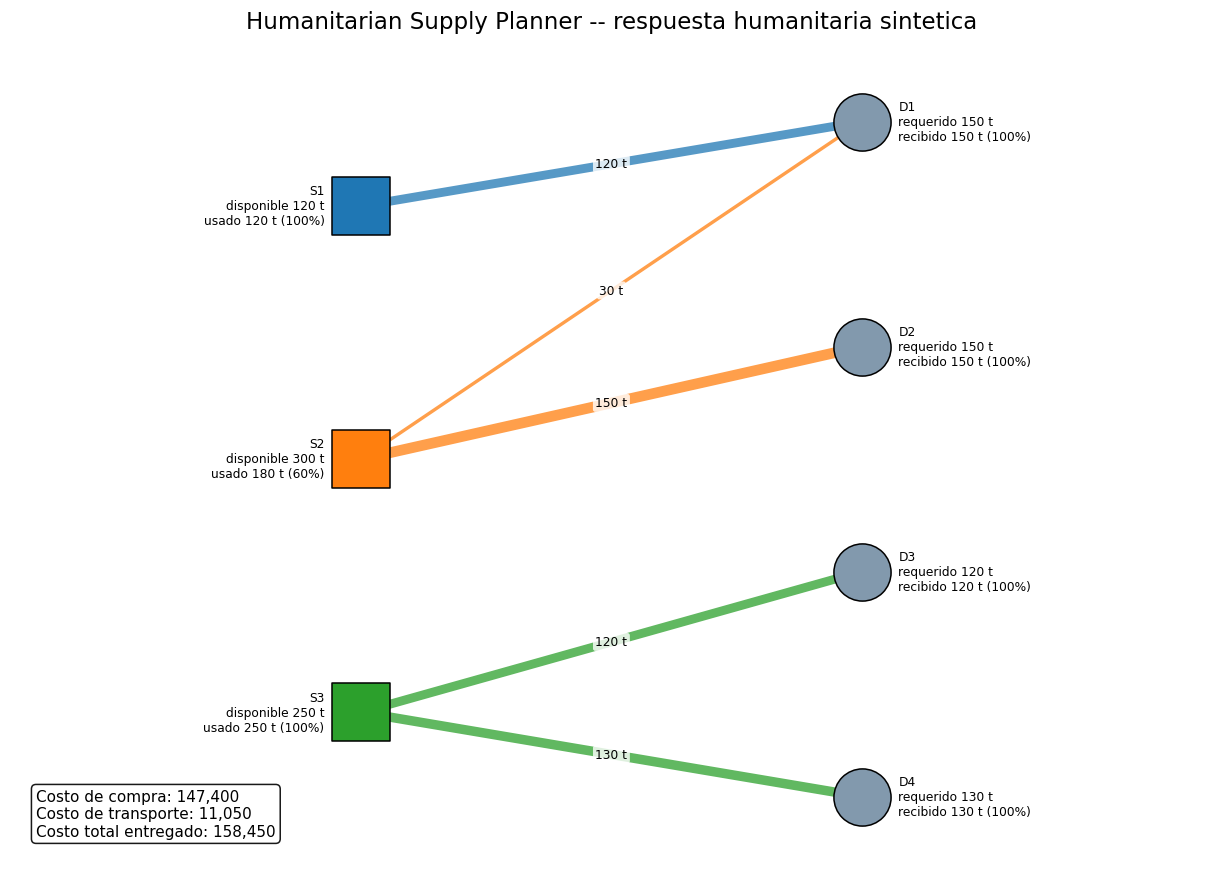

In [27]:
# El planeador completo es el producto de decision: cuanto comprar y hacia donde enviarlo.

planner_ax.set_title(
    "Humanitarian Supply Planner -- respuesta humanitaria sintetica", fontsize=15
)
summary_text = (
    f"Costo de compra: {procurement_cost_total:,.0f}\n"
    f"Costo de transporte: {transport_cost_total:,.0f}\n"
    f"Costo total entregado: {delivered_cost_total:,.0f}"
)
planner_ax.text(
    -0.65,
    0.05,
    summary_text,
    ha="left",
    va="bottom",
    fontsize=10,
    bbox=dict(boxstyle="round", facecolor="white", edgecolor="black", alpha=0.9),
)
display(planner)

In [28]:
# Verificamos el caso completo antes de generar los artefactos de entrega.

assert suppliers.available_tonnes.sum() == 670
assert destinations.required_tonnes.sum() == 550
assert np.isclose(procurement_first_cost, 163350)
assert np.isclose(greedy_a_cost, 158450)
assert np.isclose(greedy_b_cost, 159650)
assert pulp.LpStatus[status] == "Optimal"
assert np.isclose(solver_objective, 158450)
assert np.isclose(solver_objective, greedy_a_cost)
assert solver_objective <= procurement_first_cost
assert solver_objective <= greedy_b_cost
assert np.allclose(
    capacity_sensitivity.total_delivered_cost.tolist(), [158450, 157100, 156050]
)
assert (capacity_sensitivity.total_delivered_cost.diff().dropna() <= 1e-6).all()
opp = opportunity_cost.set_index("destination_id")
assert np.isclose(opp.loc["D1", "penalty_per_tonne"], 45)
assert np.isclose(opp.loc["D2", "penalty_per_tonne"], 35)
assert np.isclose(capacity_sensitivity.savings_per_tonne.iloc[1], 45)
assert np.isclose(capacity_sensitivity.savings_per_tonne.iloc[2], 35)
cap120 = capacity_sensitivity.set_index("s1_capacity_tonnes")
assert np.isclose(cap120.loc[120, "s1_to_d1_tonnes"], 120)
assert np.isclose(cap120.loc[150, "s1_to_d1_tonnes"], 150)
assert np.isclose(cap120.loc[180, "s1_to_d1_tonnes"], 150)
assert np.isclose(cap120.loc[180, "s1_to_d2_tonnes"], 30)
assert np.isclose(shipment_plan.tonnes.sum(), 550)
print(
    "Verificado: heuristicas, optimo HiGHS y sensibilidad coinciden con los valores esperados del caso aprobado."
)

Verificado: heuristicas, optimo HiGHS y sensibilidad coinciden con los valores esperados del caso aprobado.


In [29]:
# Guardamos el plan optimizado, la utilizacion, la comparacion y el planeador; no se vuelve a mostrar.

submission_dir.mkdir(exist_ok=True)
shipment_plan.to_csv(submission_dir / "shipment_plan.csv", index=False)
supplier_utilization[
    ["supplier_id", "available_tonnes", "tonnes_used", "utilization_pct"]
].to_csv(submission_dir / "supplier_utilization.csv", index=False)
plan_comparison.to_csv(submission_dir / "plan_comparison.csv", index=False)
planner.savefig(
    submission_dir / "humanitarian_supply_planner.png",
    dpi=180,
    bbox_inches="tight",
    facecolor="white",
)
display(
    [
        str(submission_dir / name)
        for name in [
            "shipment_plan.csv",
            "supplier_utilization.csv",
            "plan_comparison.csv",
            "humanitarian_supply_planner.png",
        ]
    ]
)

['../submission/shipment_plan.csv',
 '../submission/supplier_utilization.csv',
 '../submission/plan_comparison.csv',
 '../submission/humanitarian_supply_planner.png']